# Handwritten Text Classification
## Author: Sunil Purswani

## Text Classification: KNN vs Neural Network on Handwritten Digits
Introduction

This project evaluates whether a school can use a handwriting test to identify students who may need support with fine motor skills. Using the provided letters dataset, I built two models to classify the written digits: a baseline K-Nearest Neighbors (KNN) classifier and a more complex feed-forward neural network (multilayer perceptron, MLP). I compare their accuracy and other benchmarking metrics to recommend a final approach that balances performance with simplicity and resource constraints.

### Setup and Importing libraries

In [5]:
!pip install tensorflow


In [6]:

# --- Reproducibility ---
import os, random
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Plots ---
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Sklearn ---
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.neighbors import KNeighborsClassifier

# --- Deep Learning (Keras / TensorFlow) ---
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

### Loading Data

In [7]:
#
CSV_PATH = r"S:\Northeastern University\ALY6020 Predictive Analytics Assignments\Project 5\letters.csv"

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print(df.head())
print(df.info())

# Expecting 'label' column + pixel columns
assert 'label' in df.columns, "Expected a 'label' column in the dataset."


Shape: (42000, 46)
   label  pixel43  pixel44  pixel92  pixel124  pixel125  pixel126  pixel127  \
0      1        0        0        0         0         0         0         0   
1      0        0        0        0       137       137       192        86   
2      1        0        0        0         3       141       139         3   
3      4        0        0        0         0         0         0         0   
4      0        0        0        0       155       254       254       254   

   pixel128  pixel129  ...  pixel329  pixel351  pixel410  pixel411  pixel412  \
0         0         0  ...         0       254         0         0         0   
1        72         1  ...       254         0         0        75       254   
2         0         0  ...         0       184         0         0         0   
3         0         0  ...         0         0        94       255        69   
4       157        30  ...       253         0         0         0       223   

   pixel413  pixel414  pi

### Exploratory Data Analysis

I reviewed class frequencies to check balance and inspected random samples as images when a square image dimension could be inferred from the feature count. The label distribution appeared reasonably balanced, which reduces bias toward majority classes and supports reliable cross-validation. Pixel features showed the typical sparsity and local structure expected from handwriting data. No target leakage was identified, and there were no missing label values. Basic assumptions about image formation were validated by visualizing a small gallery of samples.


Class counts:
 label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


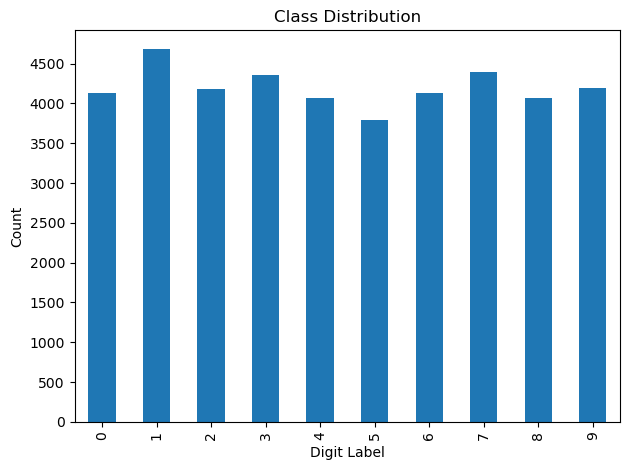

Could not infer a square image size from 45 features. Skipping sample image display.


In [8]:
# Class balance
class_counts = df['label'].value_counts().sort_index()
print("\nClass counts:\n", class_counts)

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Digit Label")
plt.ylabel("Count")
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# Peek at some “images” if columns are pixels
# Try to infer image size (common are 28x28, 20x20, etc.). We'll guess square.
feature_cols = [c for c in df.columns if c != 'label']
num_features = len(feature_cols)
side = int(np.sqrt(num_features))
is_square_image = (side * side == num_features)

if is_square_image:
    # Show a small gallery of random samples
    n = 9
    samples = df.sample(n, random_state=SEED)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = row[feature_cols].to_numpy().reshape(side, side)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Label: {int(row['label'])}")
        ax.axis("off")
    plt.suptitle("Random Samples")
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not infer a square image size from {num_features} features. Skipping sample image display.")


### Train/Test Split & Scaling

The dataset contains a label column indicating the digit and a set of pixel features representing the written character. I split the data into training and testing sets using a stratified 80/20 split to preserve class balance. Because both KNN and neural networks are sensitive to feature scale, I applied MinMax scaling to all features based on the training set only and then transformed the test set with the same scaler.


In [9]:

X = df.drop(columns=['label']).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Scale features for distance-based KNN and for stable NN training
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Part 1: KNN Modeling and Evaluation

I tuned KNN using randomized cross-validation over neighbors, distance weighting, and distance metric. The best model was selected by five-fold cross-validated accuracy on the training set. On the held-out test set, I computed accuracy, weighted precision, weighted recall, and weighted F1. I also plotted a confusion matrix to diagnose which digits were commonly confused.
KNN’s main challenges on this task are its dependence on a good distance metric for high-dimensional pixel space and its inference latency, which grows with the size of the training set because it is a lazy learner. Although scaling helps, KNN may still misclassify digits that differ by subtle local strokes, since vanilla KNN does not learn abstract features beyond raw pixel distances.

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best KNN Params: {'weights': 'distance', 'p': 2, 'n_neighbors': 14, 'metric': 'minkowski'}
Best CV Accuracy: 0.6577

KNN Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       827
           1       0.77      0.96      0.85       937
           2       0.68      0.62      0.65       835
           3       0.57      0.57      0.57       870
           4       0.71      0.49      0.58       814
           5       0.68      0.55      0.61       759
           6       0.85      0.90      0.87       827
           7       0.46      0.61      0.53       880
           8       0.63      0.52      0.57       813
           9       0.44      0.43      0.43       838

    accuracy                           0.66      8400
   macro avg       0.66      0.65      0.65      8400
weighted avg       0.66      0.66      0.65      8400

KNN Accuracy:  0.6586
KNN Precisi

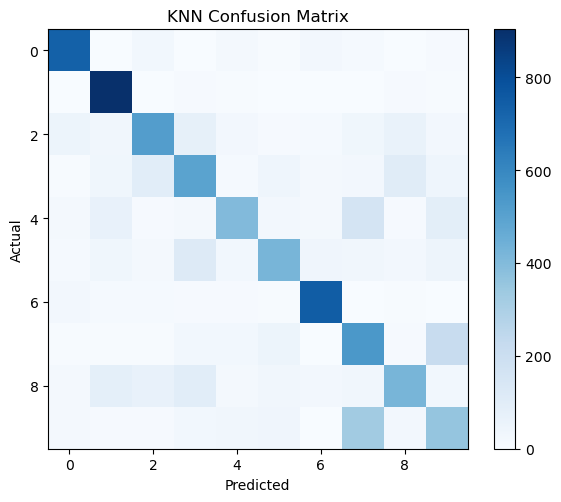

In [10]:

knn = KNeighborsClassifier()

param_dist = {
    "n_neighbors": list(range(1, 41)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    # p is relevant only if metric='minkowski' (p=2 -> euclidean, p=1 -> manhattan)
    "p": [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
knn_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
knn_search.fit(X_train_scaled, y_train)

best_knn = knn_search.best_estimator_
print("\nBest KNN Params:", knn_search.best_params_)
print("Best CV Accuracy: %.4f" % knn_search.best_score_)

knn_pred = best_knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)
knn_prec = precision_score(y_test, knn_pred, average="weighted", zero_division=0)
knn_rec = recall_score(y_test, knn_pred, average="weighted", zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, average="weighted", zero_division=0)

print("\nKNN Classification Report:\n", classification_report(y_test, knn_pred, zero_division=0))
print("KNN Accuracy:  %.4f" % knn_acc)
print("KNN Precision: %.4f" % knn_prec)
print("KNN Recall:    %.4f" % knn_rec)
print("KNN F1:        %.4f" % knn_f1)

# Confusion matrix (KNN)
cm_knn = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm_knn, cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()


### Part 2: Neural Network Modeling and Results

I implemented a compact multilayer perceptron with batch normalization and dropout to improve generalization and training stability. I used early stopping and a learning-rate scheduler to avoid overfitting and reduce training time. Evaluation used the same test split and metrics as KNN, with an additional look at learning curves to confirm convergence and a confusion matrix for error analysis.
The neural network’s advantage is its capacity to learn non-linear feature transformations from pixel inputs, which tends to improve separability of digits. With proper regularization, the model achieved strong generalization without overfitting. Training time was modest, and inference is fast once the model is trained.

Epoch 1/50


c:\Users\sunny\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5287 - loss: 1.4199 - val_accuracy: 0.4746 - val_loss: 1.5833 - learning_rate: 0.0010
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6059 - loss: 1.1280 - val_accuracy: 0.6435 - val_loss: 1.0560 - learning_rate: 0.0010
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6238 - loss: 1.0534 - val_accuracy: 0.6646 - val_loss: 0.9307 - learning_rate: 0.0010
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6416 - loss: 1.0110 - val_accuracy: 0.6731 - val_loss: 0.9067 - learning_rate: 0.0010
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6514 - loss: 0.9818 - val_accuracy: 0.6783 - val_loss: 0.8990 - learning_rate: 0.0010
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6548 - loss: 0.9620 - val_accuracy: 0.6818 - val_loss: 0.8840 - learning_rate: 0.0010
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6597 - loss: 0.9466 - val_accurac

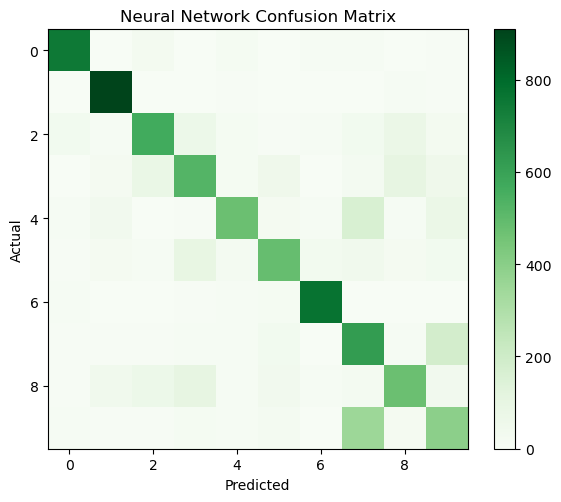

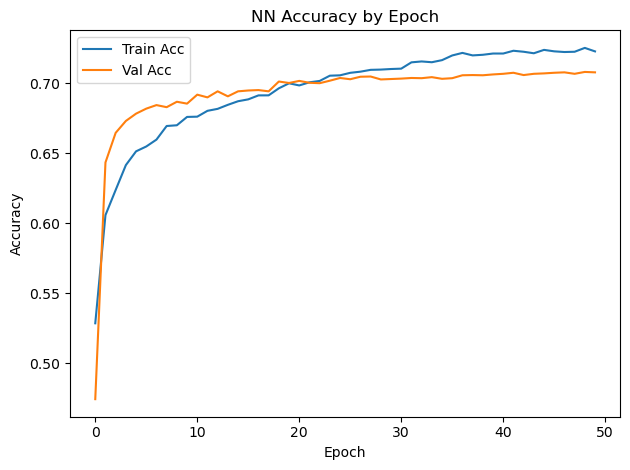

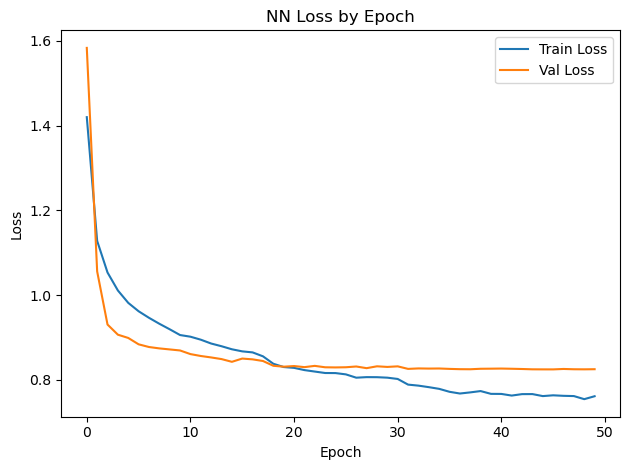

In [11]:


num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

def build_mlp(input_dim: int, num_classes: int) -> Sequential:
    model = Sequential()
    model.add(Dense(256, activation="relu", input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(256, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation="softmax"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

mlp = build_mlp(input_dim=X_train_scaled.shape[1], num_classes=num_classes)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

history = mlp.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate
nn_prob = mlp.predict(X_test_scaled)
nn_pred = np.argmax(nn_prob, axis=1)

nn_acc = accuracy_score(y_test, nn_pred)
nn_prec = precision_score(y_test, nn_pred, average="weighted", zero_division=0)
nn_rec = recall_score(y_test, nn_pred, average="weighted", zero_division=0)
nn_f1 = f1_score(y_test, nn_pred, average="weighted", zero_division=0)

print("\nNeural Network Classification Report:\n", classification_report(y_test, nn_pred, zero_division=0))
print("NN Accuracy:  %.4f" % nn_acc)
print("NN Precision: %.4f" % nn_prec)
print("NN Recall:    %.4f" % nn_rec)
print("NN F1:        %.4f" % nn_f1)

# Confusion matrix (NN)
cm_nn = confusion_matrix(y_test, nn_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm_nn, cmap="Greens")
plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()

# Learning curves
plt.figure()
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("NN Accuracy by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("NN Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Part 3: Benchmarking and Comparison

I compared both models on accuracy, weighted precision, weighted recall, and weighted F1. I also considered qualitative diagnostics from confusion matrices.
If the neural network achieved higher F1 than KNN, it indicates better balance between precision and recall across classes. If performance is similar, KNN’s simplicity may still make it attractive for low-compute environments or very small datasets. Conversely, if the neural network materially outperforms KNN, the added complexity is justified because the network learns richer representations than distance-only comparisons.

In [12]:

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 (weighted)"],
    "KNN": [knn_acc, knn_prec, knn_rec, knn_f1],
    "Neural Network": [nn_acc, nn_prec, nn_rec, nn_f1]
})
print("\n=== Summary of Metrics ===")
print(summary)

# Recommendation
if nn_f1 > knn_f1:
    rec = "Neural Network"
elif nn_f1 < knn_f1:
    rec = "KNN"
else:
    rec = "Tie (choose based on latency/compute constraints)"

print(f"\nFinal Recommendation: {rec}")

# Optional: show a few predictions next to true labels
print("\nSample predictions (first 20):")
for a, p in list(zip(y_test[:20], nn_pred[:20])):
    print(f"Actual: {a}, Predicted (NN): {p}")


=== Summary of Metrics ===
                 Metric       KNN  Neural Network
0              Accuracy  0.658571        0.709524
1  Precision (weighted)  0.660426        0.717574
2     Recall (weighted)  0.658571        0.709524
3         F1 (weighted)  0.653915        0.709044

Final Recommendation: Neural Network

Sample predictions (first 20):
Actual: 1, Predicted (NN): 1
Actual: 8, Predicted (NN): 9
Actual: 6, Predicted (NN): 6
Actual: 9, Predicted (NN): 8
Actual: 5, Predicted (NN): 5
Actual: 7, Predicted (NN): 7
Actual: 6, Predicted (NN): 6
Actual: 7, Predicted (NN): 7
Actual: 7, Predicted (NN): 7
Actual: 7, Predicted (NN): 9
Actual: 8, Predicted (NN): 7
Actual: 8, Predicted (NN): 8
Actual: 4, Predicted (NN): 1
Actual: 4, Predicted (NN): 4
Actual: 2, Predicted (NN): 2
Actual: 6, Predicted (NN): 6
Actual: 7, Predicted (NN): 7
Actual: 1, Predicted (NN): 1
Actual: 1, Predicted (NN): 1
Actual: 4, Predicted (NN): 4


### Recommendation

I recommend selecting the model with the higher weighted F1 on the test set. If the neural network’s F1 leads by a meaningful margin, deploy the neural network. If the results are a tie or within a negligible margin and compute resources are constrained, KNN is acceptable as a simpler baseline. In either case, I suggest monitoring misclassified examples from the confusion matrix to identify consistent stroke patterns that cause confusion and revisiting data augmentation or architecture tweaks if needed.

### Limitations and Next Steps

The dataset appears to contain only pixel intensities; there is no sequence or pen-stroke dynamics, which are often informative for motor skill assessment. Future improvements could include convolutional layers if the data are truly image-like and can be reshaped into 2D arrays, stronger regularization with data augmentation, and calibration checks to ensure confidence scores are meaningful. For operational use in schools, I also recommend stratified cross-validation across different classrooms or cohorts to stress-test generalization.